# Unsupervised Structure Discovery (Density Clustering)

This notebook utilizes HDBSCAN to identify dense "clouds" of constructs.
We sweep hyperparameters (`cluster_selection_epsilon`, `min_cluster_size`) and optimize for F1-score on the calibration set (ground truth pairs).

In [ ]:
import sys
import os
from pathlib import Path
import importlib

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'analysis').exists():
            return candidate
    raise RuntimeError("Could not locate project root containing scripts/ and analysis/")

PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from scripts import model_utils_clustering as model_utils
from scripts import model_utils_shared, config
import warnings

# Reload config to get latest changes
importlib.reload(config)

# Silence warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Reproducibility + deterministic output paths
SEED = model_utils_shared.setup_reproducibility(config.SEED)

PROJECT_ROOT = Path(config.PROJECT_ROOT)
RESULTS_ROOT = PROJECT_ROOT / 'analysis' / 'results'
ELSST_RESULTS_DIR = RESULTS_ROOT / 'elsst'
ELSST_CALLIBRATIONS_DIR = ELSST_RESULTS_DIR / 'callibrations_results'
ELSST_PLOTS_DIR = ELSST_RESULTS_DIR / 'plots'
ELSST_CALLIBRATIONS_DIR.mkdir(parents=True, exist_ok=True)
ELSST_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results root: {RESULTS_ROOT}")
print(f"Using seed: {SEED}")

Changed working directory to: /home/rass/Desktop/SocialScience-ConceptIntegration


/home/rass/Desktop/SocialScience-ConceptIntegration/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


42

## 1. Load Data

In [2]:
pos_path = config.DATA_PATHS['elsst']['pos_pairs']
neg_path = config.DATA_PATHS['elsst']['neg_pairs']

df = model_utils_shared.load_and_prepare_data(pos_path, neg_path, config.SEED)
print(f"Total Rows: {len(df)}")

Loading datasets...
Positive samples: 3587
Negative samples (total): 2884723
Negative samples (used as is): 2884723
Total Rows: 2888310


## 2. Clustering Run (Fixed Params)

Run one clustering pass per model using predefined parameters, then evaluate results separately.


 Processing: All-MPNet-Base-v2
Loading Model (all-mpnet-base-v2)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for All-MPNet-Base-v2...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.5085     | 0.6485     | 0.4182     | 0.4182     | 0.9997
768        | 2          | 3          | 0.4105     | 0.4697     | 0.3647     | 0.3647     | 0.9995
768        | 2          | 4          | 0.3020     | 0.4289     | 0.2331     | 0.2331     | 0.9996
768        | 2          | 5          | 0.0024     | 0.0012     | 0.9746     | 0.9746     | 0.0091
768        | 2          | 6          | 0.0025     | 0.0013     | 0.8185     | 0.8185     | 0.1928
768        | 2          | 7          | 0.0025     | 0.0012     | 0.8450     | 0.8450     | 0.1504


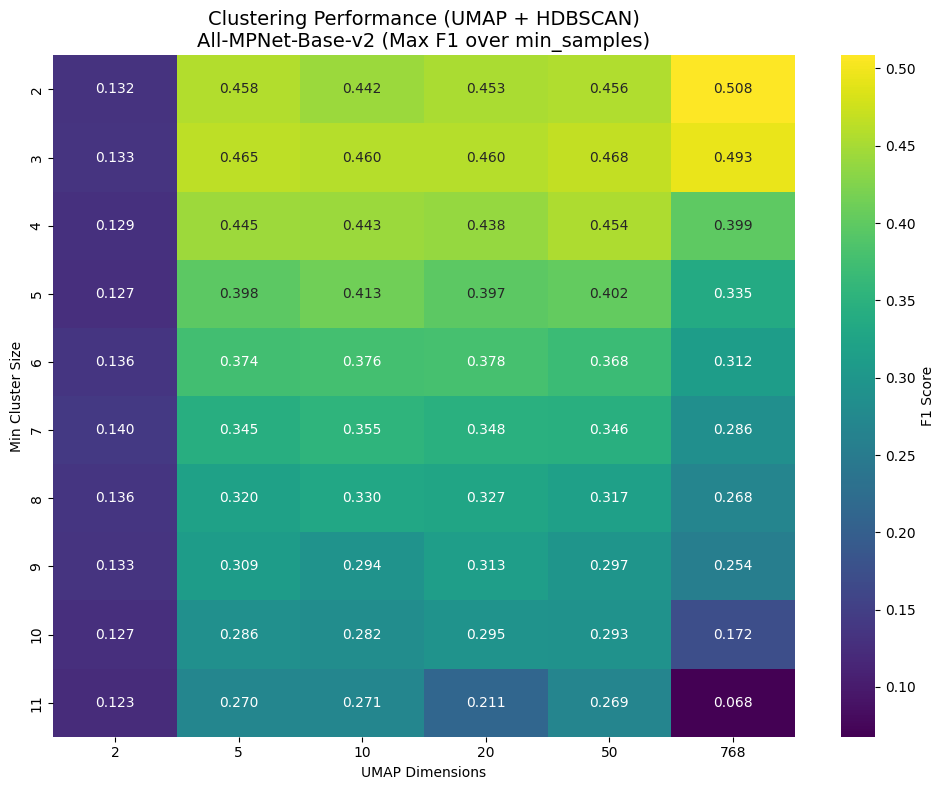


 Processing: MPNet-Personality
Loading Model (dwulff/mpnet-personality)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for MPNet-Personality...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.4823     | 0.6259     | 0.3922     | 0.3922     | 0.9997
768        | 2          | 3          | 0.4119     | 0.4682     | 0.3677     | 0.3677     | 0.9995
768        | 2          | 4          | 0.3193     | 0.3649     | 0.2838     | 0.2838     | 0.9994
768        | 2          | 5          | 0.2451     | 0.2906     | 0.2119     | 0.2119     | 0.9994
768        | 2          | 6          | 0.0026     | 0.0013     | 0.8068     | 0.8068     | 0.2232
768        | 2          | 7          | 0.0025     | 0.0013     | 0.8447     | 0.8447     | 

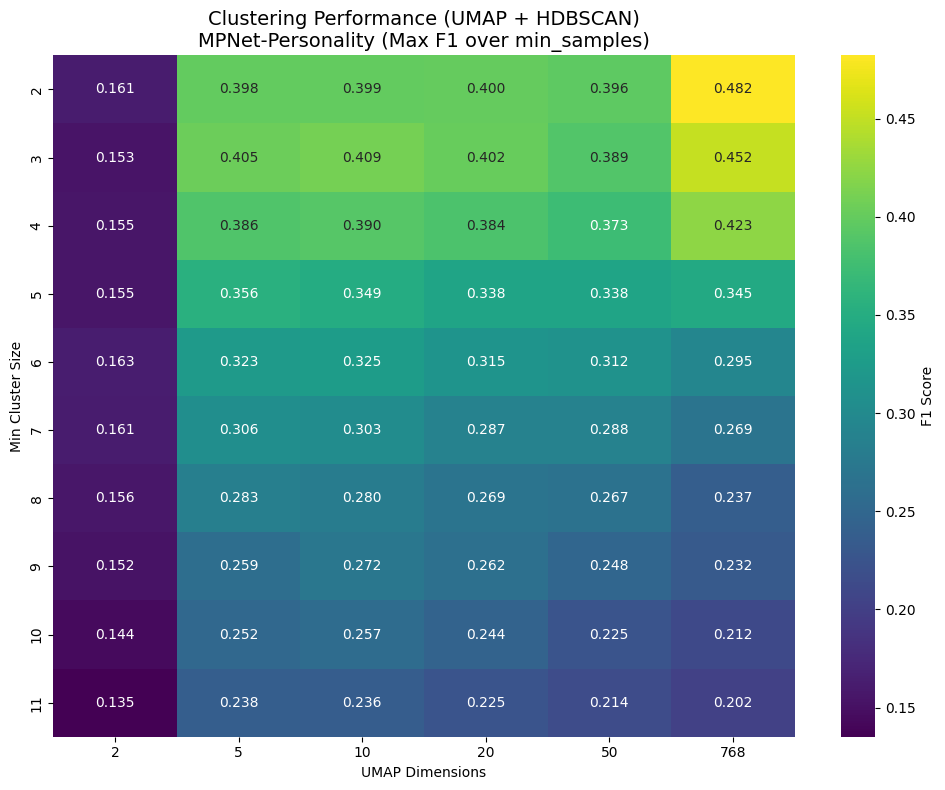


 Processing: SciBERT (SciVocab)
Loading Model (allenai/scibert_scivocab_uncased)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for SciBERT (SciVocab)...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.3088     | 0.4662     | 0.2308     | 0.2308     | 0.9997
768        | 2          | 3          | 0.1836     | 0.2068     | 0.1650     | 0.1650     | 0.9992
768        | 2          | 4          | 0.0025     | 0.0013     | 0.9208     | 0.9208     | 0.0910
768        | 2          | 5          | 0.0025     | 0.0013     | 0.9629     | 0.9629     | 0.0485
768        | 2          | 6          | 0.0025     | 0.0013     | 0.8734     | 0.8734     | 0.1334
768        | 2          | 7          | 0.0025     | 0.0012     | 0.8171     | 0.8

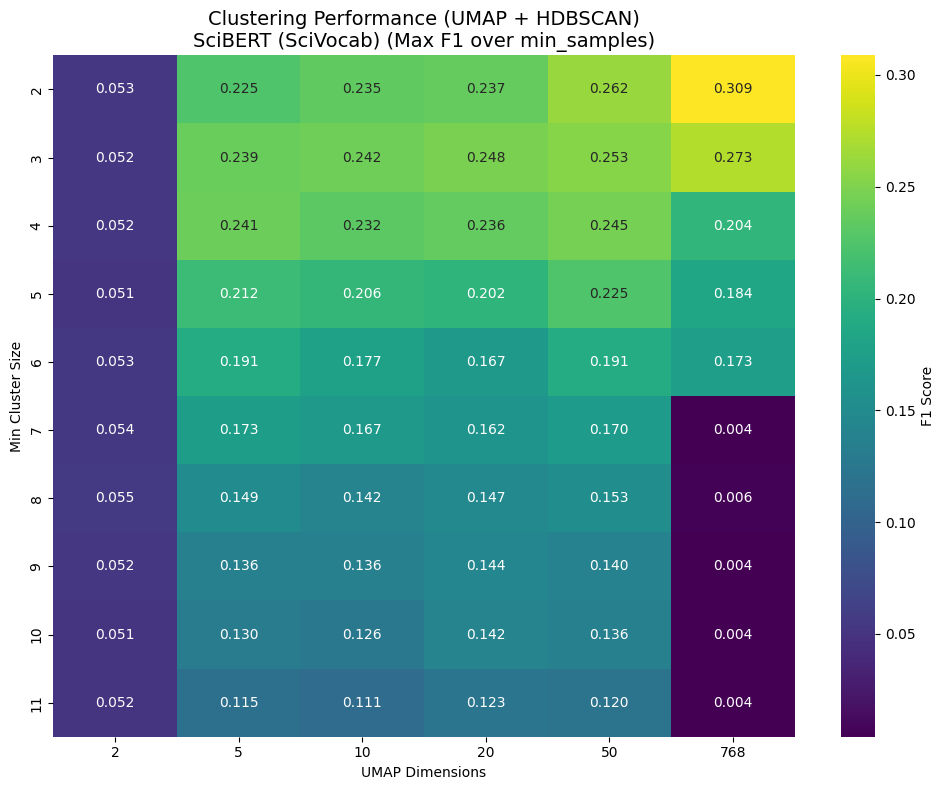


 Processing: BERT Base
Loading Model (bert-base-uncased)...
Computed embeddings for 4270 unique terms.
Optimizing Clustering for BERT Base...
Dim (UMAP) | Min Size   | Min Samp   | F1         | Precision  | Recall     | PosAcc     | NegAcc    
--------------------------------------------------------------------------------------------------------------
Using original embeddings (768 dims)...
768        | 2          | 2          | 0.2987     | 0.5000     | 0.2130     | 0.2130     | 0.9997
768        | 2          | 3          | 0.1291     | 0.1198     | 0.1399     | 0.1399     | 0.9987
768        | 2          | 4          | 0.0023     | 0.0012     | 0.8573     | 0.8573     | 0.0950
768        | 2          | 5          | 0.0023     | 0.0012     | 0.8227     | 0.8227     | 0.1171
768        | 2          | 6          | 0.0023     | 0.0011     | 0.6836     | 0.6836     | 0.2544
768        | 2          | 7          | 0.0024     | 0.0012     | 0.9495     | 0.9495     | 0.0182
768        | 2  

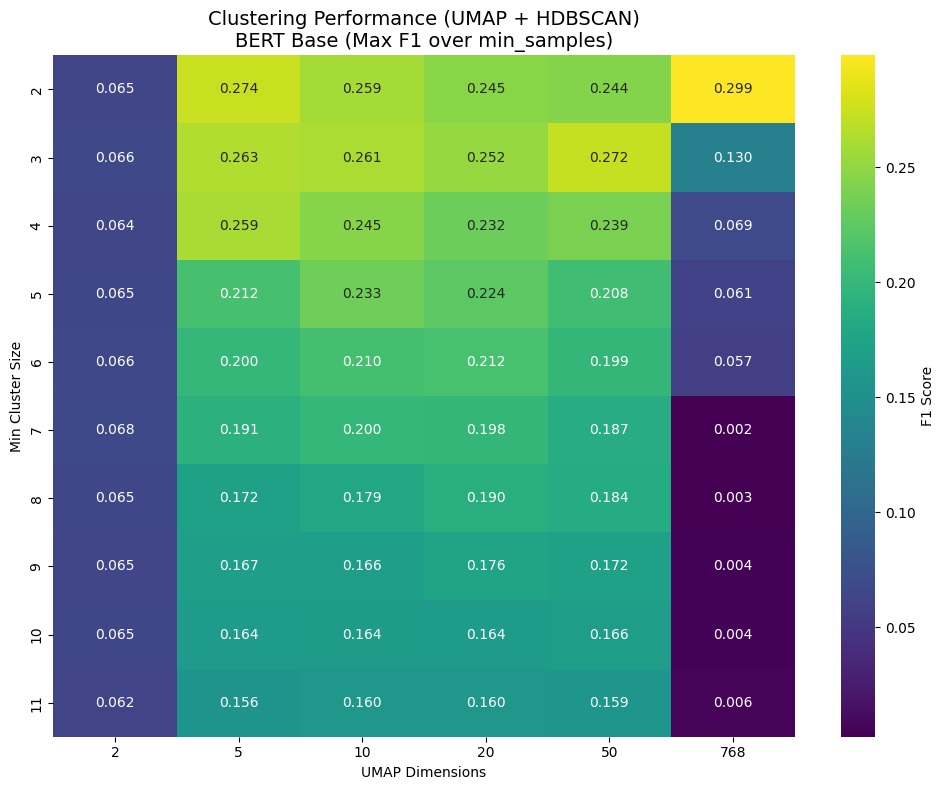

In [3]:
models_to_test = config.MODELS
all_clustering_results = []

for model_name, model_conf in models_to_test.items():
    display_name = model_conf['display_name']
    print(f"\n{'='*50}")
    print(f" Processing: {display_name}")
    print(f"{'='*50}")

    # 1. Load Model
    model = model_utils_shared.load_model(model_name, model_type=model_conf['type'])
    if model is None:
        continue

    # 2. Get Embeddings for unique terms
    unique_terms, embeddings = model_utils.get_unique_terms_embeddings(model, df)

    # 3. Sweep Hyperparameters (UMAP Components + Min Cluster Size)
    results, best_params = model_utils.run_clustering_optimization(
        display_name, 
        unique_terms, 
        embeddings, 
        df, 
        config.CLUSTERING_PARAMS['min_cluster_sizes'],
        config.CLUSTERING_PARAMS['min_samples'],
        config.CLUSTERING_PARAMS['umap_n_components']
    )
    
    all_clustering_results.extend(results)

    # 4. Plot Heatmap
    results_df = pd.DataFrame(results)
    model_utils.plot_clustering_heatmap(results_df, display_name, plots_dir=str(ELSST_PLOTS_DIR))

## 3. Summary of Best Clustering Configurations

In [4]:
full_results_df = pd.DataFrame(all_clustering_results)

# Print Summary
model_utils.print_best_clustering_settings(full_results_df)


csv_path = ELSST_CALLIBRATIONS_DIR / 'clustering_results.csv'
full_results_df.to_csv(csv_path, index=False)
print(f"\nDetailed results saved to: {csv_path}")


 BEST CLUSTERING SETTINGS PER MODEL 

Model: All-MPNet-Base-v2
  Max F1: 0.5085
  Precision: 0.6485
  Recall: 0.4182
  Pos Acc: 0.4182
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 1067
  Noise Points: 1224

Model: MPNet-Personality
  Max F1: 0.4823
  Precision: 0.6259
  Recall: 0.3922
  Pos Acc: 0.3922
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 1071
  Noise Points: 1225

Model: SciBERT (SciVocab)
  Max F1: 0.3088
  Precision: 0.4662
  Recall: 0.2308
  Pos Acc: 0.2308
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 923
  Noise Points: 1640

Model: BERT Base
  Max F1: 0.2987
  Precision: 0.5000
  Recall: 0.2130
  Pos Acc: 0.2130
  Neg Acc: 0.9997
  UMAP Dims: 768
  Min Cluster Size: 2
  Clusters Found: 889
  Noise Points: 1833

Detailed results saved to 'results/elsst/pairwise_results.csv'
